<a href="https://colab.research.google.com/github/lcandau/histopathology-clip-lab/blob/main/experiments/exp_01_baseline/CLIP_ResNet50_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CLIP ResNet50 + BERT — Baseline

**Experiment:** `exp_01_baseline` — clean controlled baseline for *A Study on Foundational Visual-Language Models for Histopathology Image Analysis*.

**Purpose of this baseline.** Versions 1–6 of this notebook mixed several experimental
variables at once (prompt strategy, partial fine-tuning of the image backbone,
and color jitter that was previously called "stain normalization"). They were
useful proof-of-concept iterations but cannot serve as a baseline because no
single ablation can be cleanly attributed against them. The baseline freezes the
methodology: every later experiment in this project changes **exactly one
variable** relative to this notebook.

**Baseline design choices (all documented in the Methodology chapter of the report).**

- **Image encoder:** ResNet50 pretrained on ImageNet, **fully frozen**.
- **Text encoder:** BERT base (uncased) pretrained on English, **fully frozen**.
- **Trainable parameters:** the two projection heads (one per modality) and
  the logit-scale temperature scalar only.
- **Prompt strategy:** a single fixed template, `"A histopathology image of
  {class_name}."`, used identically during training and evaluation.
- **Augmentation:** none. The LC25000 dataset is built from 1 250 original
  images expanded to 25 000 via the authors' rotation/flip augmentation, so
  additional geometric augmentation would be redundant and additional
  photometric augmentation would confound the future stain-normalization
  ablation.
- **Image size:** 224 × 224, matching ResNet50's ImageNet training resolution.
- **Batch size:** 32. Acknowledged limitation: with 5 classes this gives an
  average of 6.4 same-class images per batch that the InfoNCE loss treats as
  in-batch negatives. This is documented as a known false-negative pressure
  in the report; remediation (SupCon, balanced sampling) is left to future
  ablations.
- **Loss:** symmetric InfoNCE with a trainable temperature.
- **Split:** stratified 80 / 10 / 10 on the full 25 000-image dataset, seed 42,
  saved to `data/splits/lc25000_seed42.json` and committed to the repository
  so every later experiment uses the identical partition.
- **Eval:** classification via image-to-class-prompt cosine similarity. Per-
  sample retrieval R@K from CLIP's original paper is **not** applicable here
  because LC25000 has no per-image captions; we instead report a **class-level
  retrieval** view with positives defined as "any test sample of the same
  class" and explain this framing in the report.

## 0 — Setup

This cell makes the notebook self-bootstrapping on Google Colab:

1. Clones `lcandau/histopathology-clip-lab` into the runtime so `src/` is
   importable.
2. Installs the pinned dependencies from the repo's `requirements.txt`.
3. Mounts Google Drive at `/content/drive/MyDrive/clip_histopathology/` for
   persistent artifacts.

When running locally (outside Colab), it skips the Colab-specific steps and
relies on the developer's existing environment.

In [1]:
# --- Cell 0: bootstrap repo + dependencies + persistent storage ---
import os, sys, subprocess

REPO_URL = "https://github.com/lcandau/histopathology-clip-lab.git"
REPO_DIR = "/content/histopathology-clip-lab"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not os.path.exists(REPO_DIR):
        subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
    else:
        subprocess.run(["git", "-C", REPO_DIR, "pull", "--ff-only"], check=True)
    # Pin TF/Keras/KerasHub etc. to the versions recorded in requirements.txt.
    subprocess.run(
        ["pip", "install", "-q", "-r", os.path.join(REPO_DIR, "requirements.txt")],
        check=True,
    )
    if REPO_DIR not in sys.path:
        sys.path.insert(0, REPO_DIR)

    from google.colab import drive
    drive.mount("/content/drive")
else:
    # Local execution: assume the user has already activated a venv with the
    # pinned dependencies, and that this notebook lives inside the checked-out
    # repo. Add the repo root to sys.path.
    LOCAL_REPO_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
    if LOCAL_REPO_DIR not in sys.path:
        sys.path.insert(0, LOCAL_REPO_DIR)

print("In Colab:", IN_COLAB)
print("sys.path[0]:", sys.path[0])

Mounted at /content/drive
In Colab: True
sys.path[0]: /content/histopathology-clip-lab


## 1 — Imports and reproducibility

All seeds and the TensorFlow op-determinism flag are set immediately after the
imports, before any model state is constructed.

In [2]:
# --- Cell 1: imports ---
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
import keras
import keras_hub

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
import umap

# Repository helpers.
from src.utils.paths import is_colab, repo_root, drive_root, run_dir, results_dir
from src.utils.repro import set_global_seed, enable_op_determinism
from src.data.lc25000 import (
    CLASS_INFO,
    NUM_CLASSES,
    CLASS_NAMES,
    INDEX_TO_NAME,
    discover_records,
    stratified_split,
    save_split,
    load_split,
)
from src.prompts.templates import BASELINE_TEMPLATE, baseline_prompt
from src.eval.umap import fit_shared_umap, plot_umap_scatter, plot_umap_thumbnails

In [3]:
# --- Cell 2: reproducibility ---
SEED = 42
set_global_seed(SEED)
enable_op_determinism()

# Mixed precision is intentionally NOT enabled for the baseline.
#
# With both ResNet50 and BERT frozen, the projection heads + logit_scale
# scalar are the only trainable parameters, so the headline speedup from
# mixed_float16 is small. More importantly, ImageNet-pretrained ResNet50
# in float16 occasionally produces NaN activations in its BatchNorm layers
# (the running variance from float32 pretraining can underflow when used
# at float16 inference precision), which propagates into NaN losses from
# step 1. Running everything in float32 makes the baseline robust at the
# cost of ~30-40% slower training, which is acceptable here.

print("TF:", tf.__version__, "Keras:", keras.__version__, "KerasHub:", keras_hub.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TF: 2.20.0 Keras: 3.14.0 KerasHub: 0.28.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2 — Configuration

Hyperparameters are collected here so the notebook can be diff-ed cleanly
against future ablation notebooks. Every value below is the baseline
choice; ablation notebooks override exactly one of these and keep the rest.

In [4]:
# --- Cell 3: hyperparameters ---
EXPERIMENT = "exp_01_baseline"
VERSION = "baseline"

# Image input.
IMG_SIZE = 224                # 224x224, matches ImageNet pretraining of ResNet50.

# Text input.
MAX_LEN = 24                  # Longest baseline prompt tokenizes to ~14 BPE; 24 has headroom.

# Shared embedding space.
EMBED_DIM = 256

# Optimization.
BATCH_SIZE = 32
EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5
LR = 1e-3                     # Only projection heads + logit_scale train, so a normal LR is fine.
WD = 1e-4
GLOBAL_CLIPNORM = 1.0
INIT_TEMP = 0.07              # CLIP-paper initial temperature (logit_scale = ln(1/0.07) ≈ 2.66).

# Performance.
AUTOTUNE = tf.data.AUTOTUNE

# Output directories.
RUN_DIR = run_dir(EXPERIMENT, VERSION)              # persistent (Drive or local_drive/)
SPLIT_PATH = results_dir("splits") / f"lc25000_seed{SEED}.json"
METRICS_DIR = results_dir("metrics")                # committed to repo
PLOTS_DIR = results_dir("plots")                    # committed to repo
CM_DIR = results_dir("confusion_matrices")          # committed to repo

print("Run dir:", RUN_DIR)
print("Split path:", SPLIT_PATH)

Run dir: /content/drive/MyDrive/clip_histopathology/exp_01_baseline/baseline
Split path: /content/histopathology-clip-lab/data/splits/lc25000_seed42.json


## 3 — Dataset

The Kaggle LC25000 dataset
([Borkowski et al., 2019](https://arxiv.org/abs/1912.12142)) contains 25 000
JPEG patches of size 768 × 768 across five tissue classes. We download via
`kagglehub`; the first run on Colab caches the dataset under
`~/.cache/kagglehub/`.

> **Limitation noted in the report.** LC25000's 25 000 images derive from only
> 1 250 unique originals expanded by rotation/flip. Effective sample diversity
> is much lower than the file count suggests, and the dataset has known stain
> and site artifacts. we report performance on this dataset honestly; the
> report's Limitations section flags it explicitly.

In [5]:
# --- Cell 4: download dataset ---
import kagglehub

dataset_path = kagglehub.dataset_download("andrewmvd/lung-and-colon-cancer-histopathological-images")
print("Dataset root:", dataset_path)

Using Colab cache for faster access to the 'lung-and-colon-cancer-histopathological-images' dataset.
Dataset root: /kaggle/input/lung-and-colon-cancer-histopathological-images


In [6]:
# --- Cell 5: discover all records and verify class counts ---
all_paths, all_indices = discover_records(dataset_path)
print(f"Total images: {len(all_paths)}")

per_class = {INDEX_TO_NAME[i]: int((all_indices == i).sum()) for i in range(NUM_CLASSES)}
pd.Series(per_class, name="count").to_frame()

Total images: 25000


,count
benign lung tissue,5000
lung adenocarcinoma,5000
lung squamous cell carcinoma,5000
benign colon tissue,5000
colon adenocarcinoma,5000


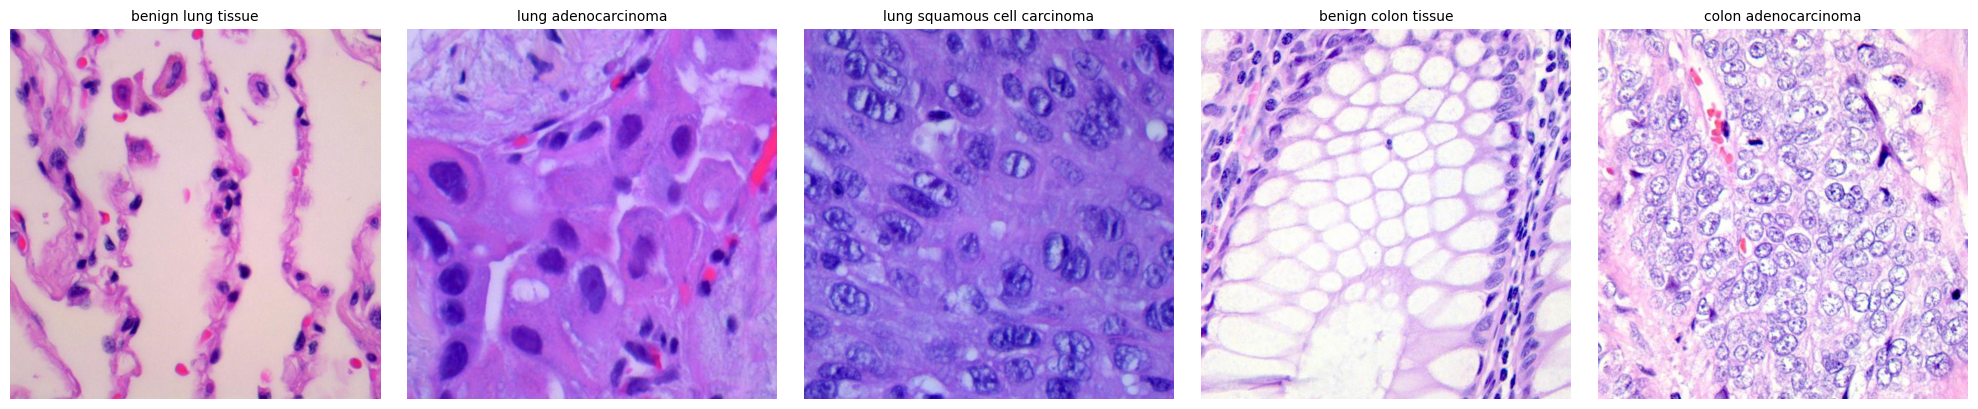

In [7]:
# --- Cell 6: visualize one sample per class ---
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(4 * NUM_CLASSES, 4))
for idx, info in enumerate(CLASS_INFO):
    sample_path = all_paths[all_indices == info.index][0]
    axes[idx].imshow(Image.open(sample_path).convert("RGB"))
    axes[idx].set_title(info.name, fontsize=10)
    axes[idx].axis("off")
plt.tight_layout()
plt.show()

## 4 — Train / validation / test split

The split is stratified 80 / 10 / 10 by class, seeded with `SEED = 42`, and
saved to `data/splits/lc25000_seed42.json` under the repository so that every
later experiment loads **exactly** the same partition.

The cell below loads an existing split if the file exists, otherwise creates
and saves a fresh one. This makes the split immutable in practice — to change
it intentionally, delete the JSON.

In [8]:
# --- Cell 7: build or load the canonical split ---
if SPLIT_PATH.exists():
    split = load_split(SPLIT_PATH)
    print(f"Loaded existing split from {SPLIT_PATH}")
else:
    split = stratified_split(all_paths, all_indices, val_fraction=0.10, test_fraction=0.10, seed=SEED)
    save_split(split, SPLIT_PATH)
    print(f"Saved new split to {SPLIT_PATH}")

train_paths, train_indices = split["train_paths"], split["train_indices"]
val_paths, val_indices = split["val_paths"], split["val_indices"]
test_paths, test_indices = split["test_paths"], split["test_indices"]

print(f"Train: {len(train_paths):>5}  Val: {len(val_paths):>5}  Test: {len(test_paths):>5}")

# Class balance sanity check.
balance = pd.DataFrame({
    "train": [int((train_indices == i).sum()) for i in range(NUM_CLASSES)],
    "val":   [int((val_indices == i).sum()) for i in range(NUM_CLASSES)],
    "test":  [int((test_indices == i).sum()) for i in range(NUM_CLASSES)],
}, index=[INDEX_TO_NAME[i] for i in range(NUM_CLASSES)])
balance

Saved new split to /content/histopathology-clip-lab/data/splits/lc25000_seed42.json
Train: 20000  Val:  2500  Test:  2500


,train,val,test
benign lung tissue,4000,500,500
lung adenocarcinoma,4000,500,500
lung squamous cell carcinoma,4000,500,500
benign colon tissue,4000,500,500
colon adenocarcinoma,4000,500,500


## 5 — Class prompts

The baseline uses a single fixed template for every class, applied
identically at train and eval time:

In [9]:
# --- Cell 8: build the class prompts ---
class_prompts = [baseline_prompt(name) for name in CLASS_NAMES]
for idx, prompt in enumerate(class_prompts):
    print(f"[{idx}] {prompt}")

[0] A histopathology image of benign lung tissue.
[1] A histopathology image of lung adenocarcinoma.
[2] A histopathology image of lung squamous cell carcinoma.
[3] A histopathology image of benign colon tissue.
[4] A histopathology image of colon adenocarcinoma.


## 6 — Input pipelines

The dataset pipeline yields `(image, token_dict)` per sample, where `image`
is a preprocessed tensor of shape `(IMG_SIZE, IMG_SIZE, 3)` and `token_dict`
is the BERT-tokenized form of the class prompt for that sample.

There is **no** training-time augmentation. Discussion: this is a deliberate
choice for the baseline — see the markdown at the top of the notebook.

In [10]:
# --- Cell 9: text preprocessor (frozen BERT tokenizer + padding) ---
text_preprocessor = keras_hub.models.BertTextClassifierPreprocessor.from_preset(
    "bert_base_en_uncased",
    sequence_length=MAX_LEN,
)

# Tokenize each class prompt once, ahead of time.
class_prompts_tf = tf.constant(class_prompts)
class_token_dict = text_preprocessor(class_prompts_tf)
print({k: v.shape for k, v in class_token_dict.items()})

{'token_ids': TensorShape([5, 24]), 'padding_mask': TensorShape([5, 24]), 'segment_ids': TensorShape([5, 24])}


In [11]:
# --- Cell 10: image loader (no augmentation) ---
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    # ResNet50 from keras-hub expects the same preprocessing as keras.applications.resnet.
    img = keras.applications.resnet.preprocess_input(img)
    return img

In [12]:
# --- Cell 11: build train / val / test datasets ---
# Per-sample we yield (image, per-class-token-fields-gathered-from-class_id).
# This avoids running the tokenizer per sample because the prompt is a function
# of the class only.

def _gather_token_dict(class_id):
    return {k: tf.gather(v, class_id) for k, v in class_token_dict.items()}

def _make_example(path, class_id):
    return load_image(path), _gather_token_dict(class_id)

def build_ds(paths, indices, shuffle: bool):
    ds = tf.data.Dataset.from_tensor_slices((paths, indices))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(_make_example, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = build_ds(train_paths, train_indices, shuffle=True)
val_ds   = build_ds(val_paths,   val_indices,   shuffle=False)

# For test we ALSO need the integer class_id for classification eval, so we keep
# both the image and the index. The token dict is unused for classification.
test_eval_ds = (
    tf.data.Dataset.from_tensor_slices((test_paths, test_indices))
    .map(lambda p, i: (load_image(p), i), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# Quick smoke test.
batch = next(iter(train_ds))
imgs, toks = batch
print("Train batch:")
print("  images:", imgs.shape, imgs.dtype)
for k, v in toks.items():
    print(f"  {k}: {v.shape} {v.dtype}")

Train batch:
  images: (32, 224, 224, 3) <dtype: 'float32'>
  token_ids: (32, 24) <dtype: 'int32'>
  padding_mask: (32, 24) <dtype: 'bool'>
  segment_ids: (32, 24) <dtype: 'int32'>


## 7 — Model

The the baseline model wraps the two frozen backbones with a small projection head per
modality and a trainable logit-scale scalar. The projection head is a single
`Dense(EMBED_DIM, use_bias=False)` followed by `LayerNormalization`, and the
output is L2-normalized so cosine similarity equals dot product.

`build_clip_model` is intentionally a function rather than a heavyweight class
hierarchy — ablations override one or two lines without needing to subclass.

In [13]:
# --- Cell 12: backbones (both frozen) ---
image_backbone = keras_hub.models.Backbone.from_preset("resnet_50_imagenet")
text_backbone  = keras_hub.models.Backbone.from_preset("bert_base_en_uncased")

image_backbone.trainable = False
text_backbone.trainable  = False

trainable_params = lambda m: sum(np.prod(v.shape) for v in m.trainable_variables)
print(f"Image backbone trainable params: {trainable_params(image_backbone):,}")
print(f"Text  backbone trainable params: {trainable_params(text_backbone):,}")

Image backbone trainable params: 0
Text  backbone trainable params: 0


In [14]:
# --- Cell 13: CLIPModel class ---
class CLIPModel(keras.Model):
    def __init__(self, img_backbone, text_backbone, embed_dim=EMBED_DIM, init_temp=INIT_TEMP):
        super().__init__()
        self.img_backbone = img_backbone
        self.text_backbone = text_backbone

        self.img_projection = keras.Sequential([
            keras.layers.Dense(embed_dim, use_bias=False, dtype="float32"),
            keras.layers.LayerNormalization(dtype="float32"),
        ], name="img_projection")

        self.text_projection = keras.Sequential([
            keras.layers.Dense(embed_dim, use_bias=False, dtype="float32"),
            keras.layers.LayerNormalization(dtype="float32"),
        ], name="text_projection")

        # logit_scale = ln(1 / temperature); kept in float32 for stability.
        self.logit_scale = self.add_weight(
            name="logit_scale",
            shape=(),
            initializer=keras.initializers.Constant(math.log(1.0 / init_temp)),
            trainable=True,
            dtype="float32",
        )

        self.loss_tracker = keras.metrics.Mean(name="loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def encode_image(self, images, training=False):
        # Backbone is frozen; training flag below only affects internal layers
        # like BatchNorm running stats — keep them in inference mode.
        features = self.img_backbone(images, training=False)
        # ResNet50 keras-hub backbone returns a (B, H, W, C) feature map.
        if features.shape.rank == 4:
            features = tf.reduce_mean(features, axis=[1, 2])
        x = self.img_projection(features)
        x = tf.math.l2_normalize(x, axis=-1)
        return x

    def encode_text(self, token_dict, training=False):
        out = self.text_backbone(token_dict, training=False)
        if isinstance(out, dict):
            if "pooled_output" in out:
                features = out["pooled_output"]
            elif "sequence_output" in out:
                features = out["sequence_output"][:, 0, :]
            else:
                raise ValueError(f"Unexpected BERT output keys: {list(out.keys())}")
        else:
            features = out[:, 0, :] if out.shape.rank == 3 else out
        x = self.text_projection(features)
        x = tf.math.l2_normalize(x, axis=-1)
        return x

    def _clip_loss(self, img_emb, txt_emb):
        img_emb = tf.cast(img_emb, tf.float32)
        txt_emb = tf.cast(txt_emb, tf.float32)
        # Clamp logit_scale to a safe range; matches OpenAI CLIP.
        scale = tf.exp(tf.clip_by_value(self.logit_scale, 0.0, math.log(100.0)))
        logits = tf.matmul(img_emb, txt_emb, transpose_b=True) * scale
        labels = tf.range(tf.shape(logits)[0])
        loss_i2t = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=labels, logits=logits)
        loss_t2i = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=labels, logits=tf.transpose(logits))
        return 0.5 * tf.reduce_mean(loss_i2t + loss_t2i)

    def train_step(self, data):
        images, token_dict = data
        with tf.GradientTape() as tape:
            img_emb = self.encode_image(images, training=True)
            txt_emb = self.encode_text(token_dict, training=True)
            loss = self._clip_loss(img_emb, txt_emb)
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result(),
                "temperature": tf.exp(-self.logit_scale)}

    def test_step(self, data):
        images, token_dict = data
        img_emb = self.encode_image(images, training=False)
        txt_emb = self.encode_text(token_dict, training=False)
        loss = self._clip_loss(img_emb, txt_emb)
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result(),
                "temperature": tf.exp(-self.logit_scale)}

    def call(self, inputs, training=False):
        images, token_dict = inputs
        return {
            "image_embeddings": self.encode_image(images, training=training),
            "text_embeddings":  self.encode_text(token_dict, training=training),
        }

In [15]:
# --- Cell 14: instantiate, compile, smoke test ---
model = CLIPModel(image_backbone, text_backbone)

optimizer = keras.optimizers.AdamW(
    learning_rate=LR,
    weight_decay=WD,
    global_clipnorm=GLOBAL_CLIPNORM,
)
model.compile(optimizer=optimizer)

# Build the model on a single example so save/load works downstream.
_ = model((imgs[:1], {k: v[:1] for k, v in toks.items()}), training=False)
print(f"Total trainable params (heads + logit_scale): {trainable_params(model):,}")

Total trainable params (heads + logit_scale): 721,921.0


## 8 — Training

Callbacks:

- `EarlyStopping(patience=5, restore_best_weights=True)` — stop when val loss
  has not improved for 5 epochs, then restore the best weights.
- `ReduceLROnPlateau(factor=0.5, patience=2)` — halve the LR when val loss
  plateaus for 2 epochs.
- `ModelCheckpoint` — write best weights to the run directory every epoch so
  a Colab session timeout doesn't lose progress.

In [18]:
# --- Cell 15: train ---
# Keras 3 requires the weights-only checkpoint filename to end with `.weights.h5`.
WEIGHTS_PATH = RUN_DIR / "weights.weights.h5"
HISTORY_PATH = RUN_DIR / "history.json"

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(WEIGHTS_PATH),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

# Persist training history so later cells (and ablation notebooks) can render
# the loss curve without re-training.
HISTORY_PATH.write_text(json.dumps(history.history))
print(f"Saved weights -> {WEIGHTS_PATH}")
print(f"Saved history -> {HISTORY_PATH}")

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - loss: 3.2061 - temperature: 0.0673
Epoch 1: val_loss improved from None to 3.15701, saving model to /content/drive/MyDrive/clip_histopathology/exp_01_baseline/baseline/weights.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/clip_histopathology/exp_01_baseline/baseline/weights.weights.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 174s 277ms/step - loss: 3.1926 - temperature: 0.0667 - val_loss: 3.1570 - val_temperature: 0.0667 - learning_rate: 0.0010
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - loss: 3.1501 - temperature: 0.0656
Epoch 2: val_loss improved from 3.15701 to 3.07244, saving model to /content/drive/MyDrive/clip_histopathology/exp_01_baseline/baseline/weights.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/clip_histopathology/exp_01_baseline/baseline/weights.weights.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 174s 278ms/step - loss: 3.1368 - temperature: 0.0644 - val_loss: 3.0724 - val_temperatu

## 9 — Resume from a previous run *(skip if you just trained)*

If `weights.h5` already exists on Drive, you can re-instantiate the model and
load the trained weights without re-running training. This is what the
ablation notebooks call to get to a known-good baseline checkpoint.

In [19]:
# --- Cell 16: re-instantiate from disk (optional) ---
if WEIGHTS_PATH.exists():
    # Rebuild the model graph and load weights.
    fresh_model = CLIPModel(image_backbone, text_backbone)
    _ = fresh_model((imgs[:1], {k: v[:1] for k, v in toks.items()}), training=False)
    fresh_model.load_weights(WEIGHTS_PATH)
    model = fresh_model

    if HISTORY_PATH.exists():
        history_dict = json.loads(HISTORY_PATH.read_text())
    else:
        history_dict = None
    print(f"Reloaded model from {WEIGHTS_PATH}")
else:
    # We just trained — use the in-memory model and history.
    history_dict = history.history
    print("Using freshly trained model.")

Reloaded model from /content/drive/MyDrive/clip_histopathology/exp_01_baseline/baseline/weights.weights.h5


## 10 — Evaluation: classification

Every test image is embedded once. Predictions are produced by taking the
argmax of cosine similarity between the image embedding and the 5 class-prompt
embeddings (computed once from the trained text head).

In [20]:
# --- Cell 17: compute the 5 class-prompt embeddings ---
class_text_embeddings = model.encode_text(class_token_dict, training=False).numpy()
print("Class text embeddings:", class_text_embeddings.shape)

Class text embeddings: (5, 256)


In [21]:
# --- Cell 18: classify the test set ---
test_image_embeddings_list = []
test_class_ids_list = []
predicted_class_ids_list = []

for images, true_class_ids in test_eval_ds:
    image_embeddings = model.encode_image(images, training=False).numpy()
    # Cosine similarity matrix shape (B, NUM_CLASSES).
    similarity_scores = image_embeddings @ class_text_embeddings.T
    predicted_class_ids = similarity_scores.argmax(axis=1).astype(np.int32)

    test_image_embeddings_list.append(image_embeddings)
    test_class_ids_list.append(true_class_ids.numpy())
    predicted_class_ids_list.append(predicted_class_ids)

test_image_embeddings = np.concatenate(test_image_embeddings_list, axis=0)
true_class_ids = np.concatenate(test_class_ids_list, axis=0).astype(np.int32)
predicted_class_ids = np.concatenate(predicted_class_ids_list, axis=0)

print("Test image embeddings:", test_image_embeddings.shape)
print("True / predicted shapes:", true_class_ids.shape, predicted_class_ids.shape)

Test image embeddings: (2500, 256)
True / predicted shapes: (2500,) (2500,)


In [22]:
# --- Cell 19: classification metrics ---
acc      = accuracy_score(true_class_ids, predicted_class_ids)
bal_acc  = balanced_accuracy_score(true_class_ids, predicted_class_ids)
macro_f1 = f1_score(true_class_ids, predicted_class_ids, average="macro")
wgt_f1   = f1_score(true_class_ids, predicted_class_ids, average="weighted")

global_metrics = {
    "accuracy": float(acc),
    "balanced_accuracy": float(bal_acc),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(wgt_f1),
}
print("Global metrics:")
for k, v in global_metrics.items():
    print(f"  {k:>18}: {v:.4f}")

per_class_report = classification_report(
    true_class_ids,
    predicted_class_ids,
    labels=list(range(NUM_CLASSES)),
    target_names=[INDEX_TO_NAME[i] for i in range(NUM_CLASSES)],
    output_dict=True,
    zero_division=0,
)
per_class_df = pd.DataFrame(per_class_report).T
per_class_df

Global metrics:
            accuracy: 0.6356
   balanced_accuracy: 0.6356
            macro_f1: 0.6273
         weighted_f1: 0.6273


,precision,recall,f1-score,support
benign lung tissue,0.639344,0.7020,0.669209,500.0000
lung adenocarcinoma,0.523697,0.4420,0.479393,500.0000
lung squamous cell carcinoma,0.704698,0.8400,0.766423,500.0000
benign colon tissue,0.630017,0.7220,0.672880,500.0000
colon adenocarcinoma,0.655556,0.4720,0.548837,500.0000
accuracy,0.635600,0.6356,0.635600,0.6356
macro avg,0.630662,0.6356,0.627348,2500.0000
weighted avg,0.630662,0.6356,0.627348,2500.0000


In [23]:
# --- Cell 20: save metrics ---
metrics_path = METRICS_DIR / f"{VERSION}_classification.json"
metrics_path.write_text(json.dumps({
    "experiment": EXPERIMENT,
    "version": VERSION,
    "seed": SEED,
    "global": global_metrics,
    "per_class": per_class_report,
}, indent=2))

per_class_csv_path = METRICS_DIR / f"{VERSION}_per_class.csv"
per_class_df.to_csv(per_class_csv_path)

print(f"Saved -> {metrics_path}")
print(f"Saved -> {per_class_csv_path}")

Saved -> /content/histopathology-clip-lab/results/metrics/baseline_classification.json
Saved -> /content/histopathology-clip-lab/results/metrics/baseline_per_class.csv


## 11 — Confusion matrices

Both raw counts and row-normalized proportions. The normalized matrix is the
more informative view because it shows, per true class, how the model
distributes its predictions.

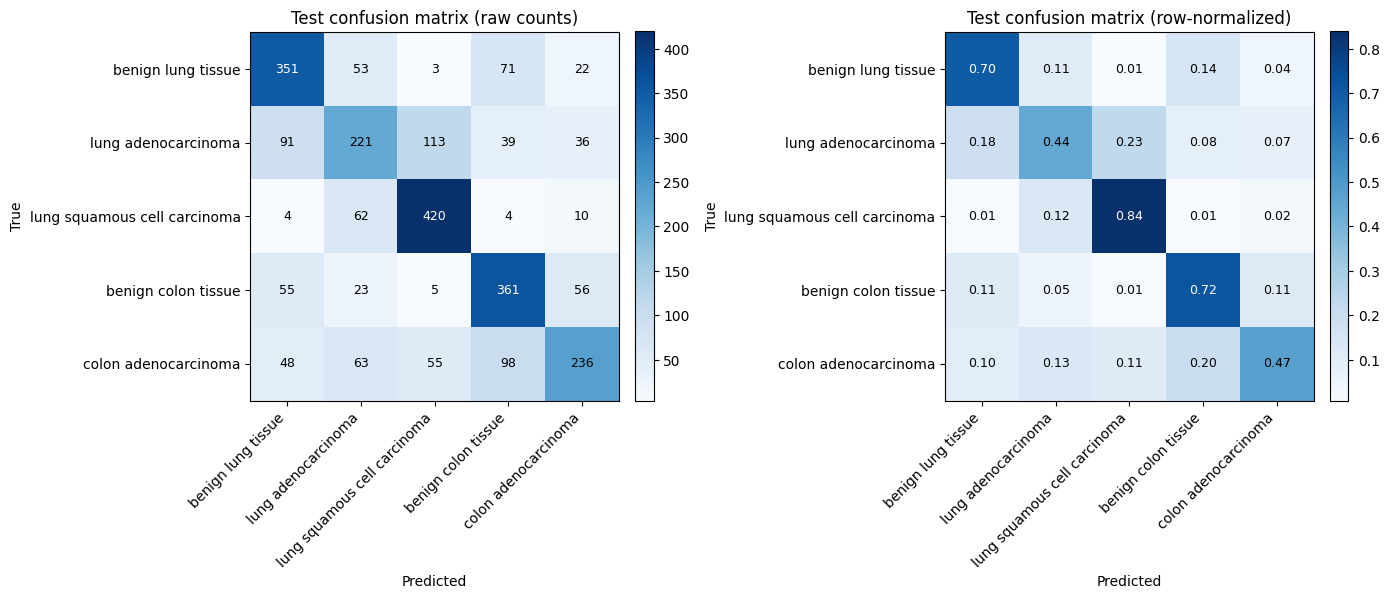

Saved -> /content/histopathology-clip-lab/results/confusion_matrices/baseline_confusion_matrices.png


In [24]:
# --- Cell 21: confusion matrices ---
cm_raw = confusion_matrix(true_class_ids, predicted_class_ids, labels=list(range(NUM_CLASSES)))
row_sums = cm_raw.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm_raw, row_sums, where=row_sums > 0, out=np.zeros_like(cm_raw, dtype=np.float64))

display_labels = [INDEX_TO_NAME[i] for i in range(NUM_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, matrix, title, fmt, cmap in [
    (axes[0], cm_raw,  "Test confusion matrix (raw counts)",   "d",   "Blues"),
    (axes[1], cm_norm, "Test confusion matrix (row-normalized)", ".2f", "Blues"),
]:
    im = ax.imshow(matrix, cmap=cmap)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(display_labels, rotation=45, ha="right")
    ax.set_yticklabels(display_labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            val = matrix[i, j]
            ax.text(j, i, format(val, fmt), ha="center", va="center",
                    color="white" if val > matrix.max() * 0.6 else "black",
                    fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

cm_plot_path = CM_DIR / f"{VERSION}_confusion_matrices.png"
fig.savefig(cm_plot_path, dpi=150, bbox_inches="tight")
plt.show()

np.save(CM_DIR / f"{VERSION}_cm_raw.npy", cm_raw)
np.save(CM_DIR / f"{VERSION}_cm_norm.npy", cm_norm)
print(f"Saved -> {cm_plot_path}")

## 12 — Training curves

Train and validation loss. The temperature curve (the learned `1 / exp(logit_scale)`) is useful as a sanity check: it should drift away from the
initial value and stabilize.

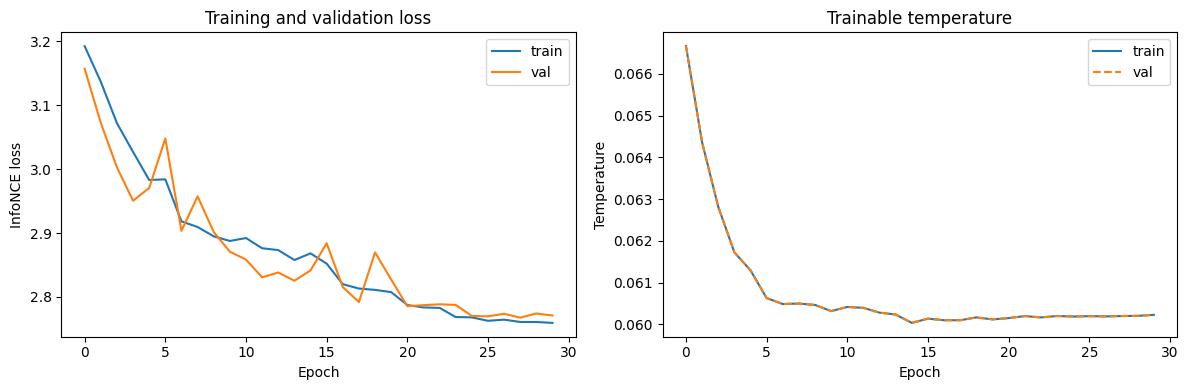

Saved -> /content/histopathology-clip-lab/results/plots/baseline_loss.png


In [25]:
# --- Cell 22: plot training history ---
if history_dict is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_dict["loss"], label="train")
    if "val_loss" in history_dict:
        axes[0].plot(history_dict["val_loss"], label="val")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("InfoNCE loss")
    axes[0].set_title("Training and validation loss")
    axes[0].legend()

    if "temperature" in history_dict:
        axes[1].plot(history_dict["temperature"], label="train")
    if "val_temperature" in history_dict:
        axes[1].plot(history_dict["val_temperature"], label="val", linestyle="--")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Temperature")
    axes[1].set_title("Trainable temperature")
    axes[1].legend()

    plt.tight_layout()
    loss_plot_path = PLOTS_DIR / f"{VERSION}_loss.png"
    fig.savefig(loss_plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {loss_plot_path}")
else:
    print("No history available (model was reloaded without history.json).")

## 13 — Embedding visualizations

Three views of how the model places the test set in its learned 256-dimensional
embedding space, all built from a single UMAP fit on the concatenation of
the test image embeddings and the five class-prompt embeddings (so images
and prompts share one coordinate system):

1. **Vanilla shared UMAP** — per-class image scatter with the five
   class-prompt embeddings marked on top. Tight, well-separated clusters
   that line up with their own prompt indicate strong cross-modal alignment.
2. **Thumbnail UMAP (tutor-style)** — same coordinate system, but ~50 sample
   image thumbnails are sprinkled around the space using a `min_dist` rule,
   and the prompt markers are laid on top. This makes the qualitative
   structure of each region visible.
3. **Class-prompt similarity heatmap.** For each true class we average the
   image embeddings of its test samples, then compute cosine similarity
   against all 5 class-prompt embeddings. A diagonal-heavy matrix means
   each class's centroid aligns most strongly with its own prompt.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


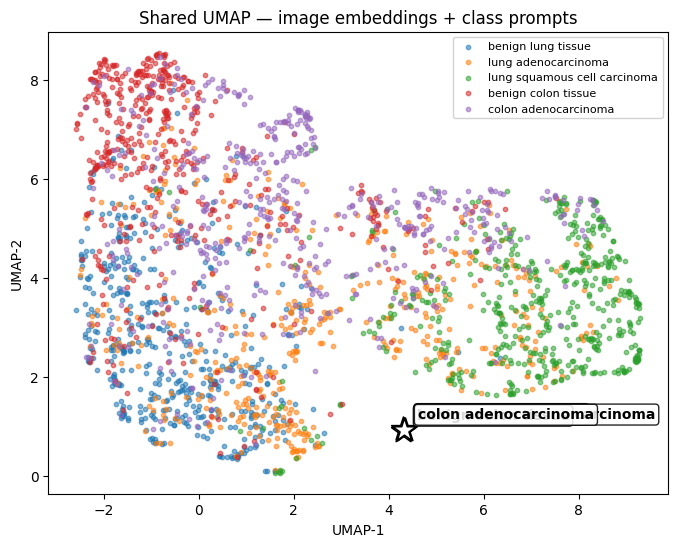

Saved -> /content/histopathology-clip-lab/results/plots/baseline_umap.png


In [26]:
# --- Cell 23a: shared UMAP fit (images || class prompts) ---
image_2d, text_2d = fit_shared_umap(
    test_image_embeddings, class_text_embeddings,
    n_neighbors=15, min_dist=0.1, metric="cosine", random_state=SEED,
)

class_names = [INDEX_TO_NAME[i] for i in range(NUM_CLASSES)]

fig = plot_umap_scatter(
    image_2d=image_2d, image_labels=true_class_ids,
    text_2d=text_2d, class_names=class_names,
    title="Shared UMAP — image embeddings + class prompts",
)
umap_path = PLOTS_DIR / f"{VERSION}_umap.png"
fig.savefig(umap_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {umap_path}")

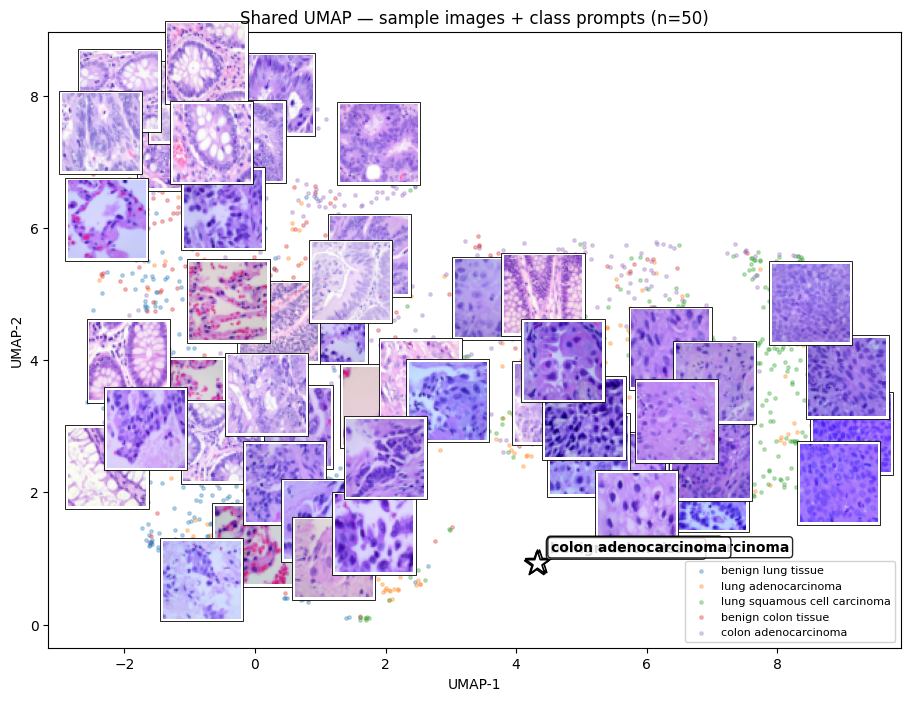

Saved -> /content/histopathology-clip-lab/results/plots/baseline_umap_thumbnails.png


In [27]:
# --- Cell 23b: thumbnail UMAP (tutor-style) with prompts on top ---
fig = plot_umap_thumbnails(
    image_2d=image_2d, image_paths=list(test_paths), image_labels=true_class_ids,
    text_2d=text_2d, class_names=class_names,
    max_thumbs=50, thumb_size=(56, 56), min_dist_frac=0.05, seed=SEED,
    title="Shared UMAP — sample images + class prompts",
)
umap_thumbs_path = PLOTS_DIR / f"{VERSION}_umap_thumbnails.png"
fig.savefig(umap_thumbs_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {umap_thumbs_path}")

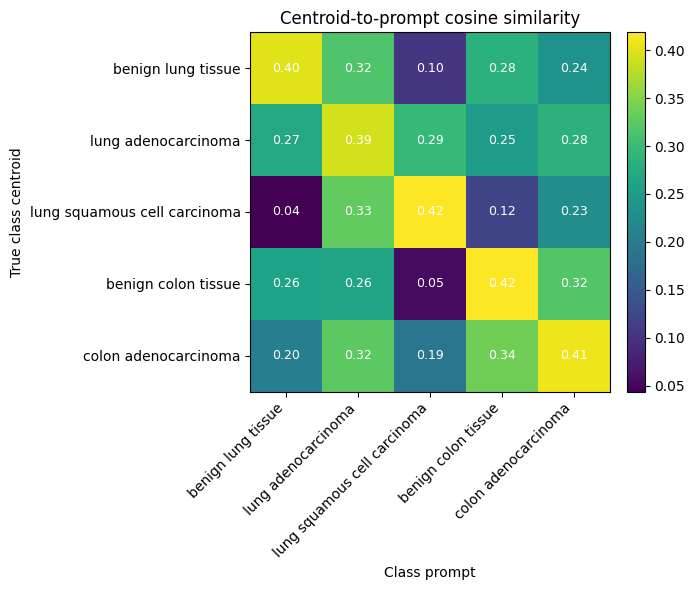

Saved -> /content/histopathology-clip-lab/results/plots/baseline_class_similarity.png


In [28]:
# --- Cell 24: class-prompt similarity heatmap (per-true-class centroid) ---
class_centroid_embeddings = np.stack([
    test_image_embeddings[true_class_ids == i].mean(axis=0)
    for i in range(NUM_CLASSES)
])
# Re-normalize centroids to unit length so this stays a cosine.
class_centroid_embeddings /= np.linalg.norm(class_centroid_embeddings, axis=1, keepdims=True)
similarity_heatmap = class_centroid_embeddings @ class_text_embeddings.T  # (5, 5)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(similarity_heatmap, cmap="viridis")
ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(display_labels, rotation=45, ha="right")
ax.set_yticklabels(display_labels)
ax.set_xlabel("Class prompt")
ax.set_ylabel("True class centroid")
ax.set_title("Centroid-to-prompt cosine similarity")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f"{similarity_heatmap[i, j]:.2f}",
                ha="center", va="center",
                color="white" if similarity_heatmap[i, j] < 0.5 else "black",
                fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

sim_path = PLOTS_DIR / f"{VERSION}_class_similarity.png"
fig.savefig(sim_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {sim_path}")

## 14 — Class-level retrieval *(framing matters)*

CLIP's original paper reports per-image image↔text retrieval R@K against
human-written captions. **LC25000 has no per-image captions**: every image of a
class shares the same prompt. A naïve per-sample retrieval evaluation against
shared prompts therefore measures *class-level* retrieval, not the same
quantity CLIP reports — and pretending otherwise inflates the numbers.

This section computes a **class-level retrieval** view with positives defined
explicitly:

> For the image-to-text direction, a retrieved item is a *correct* hit if any
> sample of the same class is in the top-K. For the text-to-image direction,
> we compute the retrieval against the per-class text embedding (5 unique
> queries) and the test image set.

These metrics are reported in the report alongside this caveat. Use them as a
complementary view to classification accuracy, not as a substitute for
CLIP-paper retrieval claims.

In [29]:
# --- Cell 25: image-to-text class-level retrieval ---
# Score every test image against the 5 class prompt embeddings.
# A hit at rank k is correct iff the image's true class appears within the
# top-k retrieved prompts.
i2t_similarity = test_image_embeddings @ class_text_embeddings.T  # (N_test, 5)
i2t_top_k = np.argsort(-i2t_similarity, axis=1)
i2t_correct_at_rank = (i2t_top_k == true_class_ids[:, None])
# Rank position of the correct class for each image.
i2t_correct_rank = i2t_correct_at_rank.argmax(axis=1)

i2t_recall_at_1 = float((i2t_correct_rank < 1).mean())
i2t_recall_at_5 = float((i2t_correct_rank < 5).mean())  # trivially 1.0 since only 5 classes
print(f"I→T R@1 (image to class prompt): {i2t_recall_at_1:.4f}")
print(f"I→T R@5 (image to class prompt): {i2t_recall_at_5:.4f}")

I→T R@1 (image to class prompt): 0.6356
I→T R@5 (image to class prompt): 1.0000


In [30]:
# --- Cell 26: text-to-image class-level retrieval ---
# For each class prompt, retrieve the top-K test images by cosine similarity.
# A retrieved image is correct iff it has that class as its true label.
t2i_similarity = class_text_embeddings @ test_image_embeddings.T  # (5, N_test)
ranked_indices = np.argsort(-t2i_similarity, axis=1)               # (5, N_test)

t2i_recall = {}
for k in (1, 5, 10, 50):
    hits_at_k = []
    for class_id in range(NUM_CLASSES):
        topk_indices = ranked_indices[class_id, :k]
        positives = (true_class_ids[topk_indices] == class_id).sum()
        # Recall here is "fraction of top-K that are in-class".
        # An alternative is "fraction of in-class images that are in top-K",
        # but with class sizes ~250 in the test set, K=1,5,10 are too small
        # to make that meaningful. We report precision-at-K, which is the
        # natural measure for this small-K class-level retrieval setup.
        hits_at_k.append(float(positives) / k)
    t2i_recall[f"precision_at_{k}"] = float(np.mean(hits_at_k))

print("T→I class-level retrieval (precision@K averaged over classes):")
for k, v in t2i_recall.items():
    print(f"  {k}: {v:.4f}")

T→I class-level retrieval (precision@K averaged over classes):
  precision_at_1: 0.8000
  precision_at_5: 0.7200
  precision_at_10: 0.8000
  precision_at_50: 0.8400


In [31]:
# --- Cell 27: persist retrieval metrics ---
retrieval_path = METRICS_DIR / f"{VERSION}_class_retrieval.json"
retrieval_path.write_text(json.dumps({
    "experiment": EXPERIMENT,
    "version": VERSION,
    "seed": SEED,
    "note": (
        "Class-level retrieval, NOT CLIP-paper image-text retrieval. "
        "Positives are class-shared; per-sample positives do not exist in LC25000."
    ),
    "image_to_text": {
        "recall_at_1": i2t_recall_at_1,
        "recall_at_5": i2t_recall_at_5,
    },
    "text_to_image": t2i_recall,
}, indent=2))
print(f"Saved -> {retrieval_path}")

Saved -> /content/histopathology-clip-lab/results/metrics/baseline_class_retrieval.json


## 15 — Summary

This is the baseline. Future ablation notebooks in
`experiments/exp_01_baseline/` and the variant experiments in
`experiments/exp_02_vit/` and `experiments/exp_03_dino/` each change **exactly
one variable** relative to this notebook and report the same metric bundle:

- `results/metrics/<version>_classification.json`
- `results/metrics/<version>_per_class.csv`
- `results/confusion_matrices/<version>_cm_{raw,norm}.npy`
- `results/confusion_matrices/<version>_confusion_matrices.png`
- `results/plots/<version>_{loss,umap,class_similarity}.png`
- `results/metrics/<version>_class_retrieval.json`

Weights, history, and intermediate state live in the run directory on Drive
(`/content/drive/MyDrive/clip_histopathology/exp_01_baseline/the baseline/`) so the
repo stays small.